In [1]:
import pandas as pd
import numpy as np
import os

!pip install torch torchvision torchmetrics
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans, DBSCAN, OPTICS

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA


from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score



[notice] A new release of pip is available: 24.2 -> 25.0
[notice] To update, run: pip install --upgrade pip


In [2]:
df_raw = pd.read_csv('02_real_data/real_dataset_normalized.tsv', sep='\t', index_col=0)
df_normalized = pd.read_csv('02_real_data/real_dataset_normalized.tsv', sep='\t', index_col=0)
df_normalized_groups = pd.read_csv('02_real_data/real_dataset_normalized_by_cptac.tsv', sep='\t', index_col=0)
patient_codes = df_normalized.columns

/tmp/ipykernel_20001/2116932190.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('02_real_data/real_dataset_normalized.tsv', sep='\t', index_col=0)
/tmp/ipykernel_20001/2116932190.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,1

In [3]:
conditions = df_normalized.T['Conditions']
sample_data = df_raw.T.drop(columns=['Conditions'])
sample_data_normalized = df_normalized.T.drop(columns=['Conditions'])
sample_data_group_normalized = df_normalized_groups.T.drop(columns=['Conditions'])


sample_data = sample_data.reset_index(drop=True).to_numpy(dtype=np.float32)
sample_data_normalized = sample_data_normalized.reset_index(drop=True).to_numpy(dtype=np.float32)

sample_data_group_normalized = sample_data_group_normalized.reset_index(drop=True).to_numpy(dtype=np.float32)


In [4]:
proteomics_tensor = torch.tensor(sample_data_normalized, dtype=torch.float32)

# GOAE 

In [5]:
# Define Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_3),
            nn.ReLU(),
            nn.Linear(hidden_dim_3, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

# Define Decoder
class Decoder(nn.Module):
    def __init__(self, latent_dim, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim_3),
            nn.ReLU(),
            nn.Linear(hidden_dim_3, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, input_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

# Define GOAE Model
class GOAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(GOAE, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
        self.decoder = Decoder(latent_dim, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
    
    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return z, x_reconstructed


In [6]:
# Orthogonality Loss
def orthogonality_loss(z):
    zt_z = torch.matmul(z.T, z)
    identity = torch.eye(zt_z.size(0), device=z.device)
    return torch.norm(zt_z - identity, p='fro')**2

In [7]:
# Training
def train_goae(model, data_loader, epochs=50, latent_dim=10, learning_rate=1e-3, lambda_ortho=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        total_loss = 0
        for x_batch in data_loader:
            x_batch = x_batch[0]
           
            # Forward pass
            z, x_reconstructed = model(x_batch)
            
            # Loss
            reconstruction_loss = criterion(x_reconstructed, x_batch)
            ortho_loss = orthogonality_loss(z)
            loss = reconstruction_loss + lambda_ortho * ortho_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(data_loader)}")


proteomics_ds = TensorDataset(proteomics_tensor)
proteomics_dl = DataLoader(proteomics_ds, batch_size=64, shuffle=True)
input_dim = proteomics_tensor.shape[1]
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
latent_dim = 10
epochs = 150

goae_model = GOAE(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
train_goae(goae_model, proteomics_dl, epochs=epochs)


Epoch 1, Loss: 237849.51110001406
Epoch 2, Loss: 2373.437846660614
Epoch 3, Loss: 4573.62416934967
Epoch 4, Loss: 623.7751495838165
Epoch 5, Loss: 336.09243563810986
Epoch 6, Loss: 224.48949138323465
Epoch 7, Loss: 210.32456262906393
Epoch 8, Loss: 53.11949555079142
Epoch 9, Loss: 60.95445601145426
Epoch 10, Loss: 27.582616249720257
Epoch 11, Loss: 14.154533584912619
Epoch 12, Loss: 5.428373336791992
Epoch 13, Loss: 5.428866942723592
Epoch 14, Loss: 7.634353121121724
Epoch 15, Loss: 6.664379755655925
Epoch 16, Loss: 3.6666318575541177
Epoch 17, Loss: 2.8849268754323325
Epoch 18, Loss: 2.905644694964091
Epoch 19, Loss: 2.910070220629374
Epoch 20, Loss: 2.5106643040974936
Epoch 21, Loss: 2.1574110984802246
Epoch 22, Loss: 1.8954700628916423
Epoch 23, Loss: 1.8172976573308308
Epoch 24, Loss: 1.76489253838857
Epoch 25, Loss: 1.7034002145131428
Epoch 26, Loss: 1.6774990558624268
Epoch 27, Loss: 1.6992950836817424
Epoch 28, Loss: 1.6625182628631592
Epoch 29, Loss: 1.6171377897262573
Epoch 30

In [8]:
def extract_latent_space(model, data_loader):
    model.encoder.fc.eval()
    latent_representations = []
    with torch.no_grad():
        for batch in data_loader:
            bach_latent_reepresentation = model.encoder(batch)
           
            latent_representations.append(bach_latent_reepresentation)
    return np.vstack(latent_representations)

latent_representations = extract_latent_space(goae_model, proteomics_tensor)

In [9]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
#clusters = DBSCAN(eps=1.0).fit_predict(latent_representations)
clusters = kmeans.fit_predict(latent_representations)

[' Not Reported' ' Primary Tumor' ' Solid Tissue Normal'
 'Ovarian Tumor Sample']


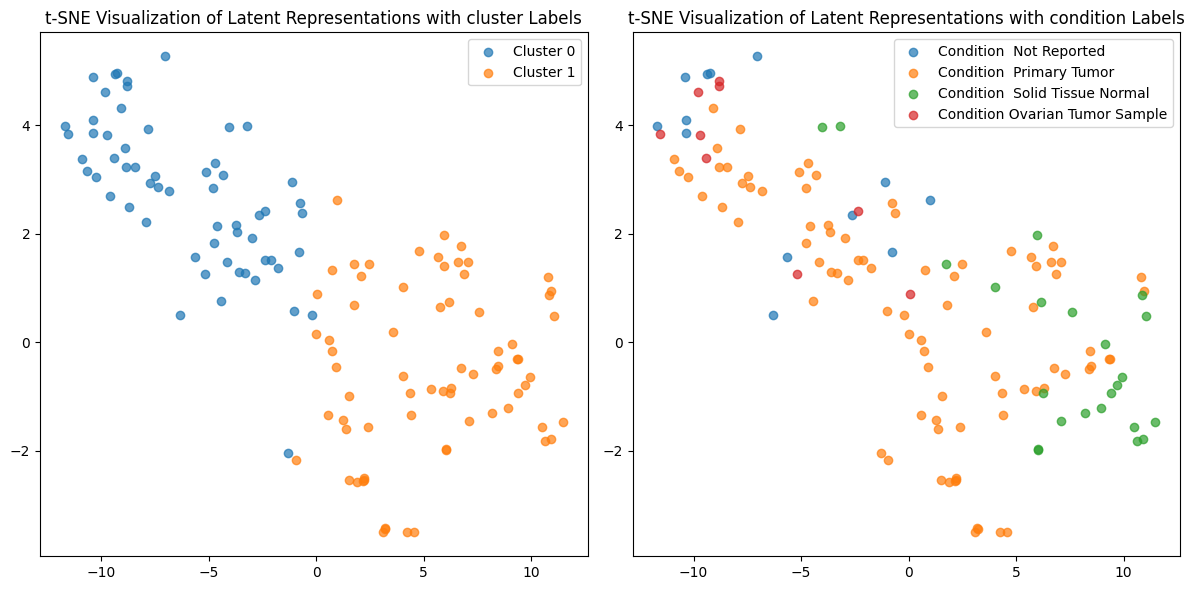

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
print(unique_conditions)

for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
index = conditions == unique_conditions[0]
#latent_2d[index, 1]
conditions

array([' Not Reported', ' Primary Tumor', ' Primary Tumor',
       ' Primary Tumor', ' Primary Tumor', ' Primary Tumor',
       ' Solid Tissue Normal', ' Primary Tumor', ' Primary Tumor',
       ' Primary Tumor', ' Not Reported', ' Primary Tumor',
       'Ovarian Tumor Sample', ' Solid Tissue Normal', ' Primary Tumor',
       ' Primary Tumor', ' Primary Tumor', ' Primary Tumor',
       ' Solid Tissue Normal', ' Primary Tumor', ' Not Reported',
       ' Primary Tumor', ' Primary Tumor', ' Solid Tissue Normal',
       ' Primary Tumor', ' Primary Tumor', ' Solid Tissue Normal',
       'Ovarian Tumor Sample', ' Primary Tumor', ' Primary Tumor',
       ' Not Reported', ' Primary Tumor', ' Primary Tumor',
       ' Primary Tumor', ' Primary Tumor', ' Primary Tumor',
       ' Primary Tumor', ' Solid Tissue Normal', ' Primary Tumor',
       ' Solid Tissue Normal', ' Not Reported', ' Primary Tumor',
       ' Primary Tumor', 'Ovarian Tumor Sample', ' Solid Tissue Normal',
       ' Primary Tumor',

In [12]:
experiment_codes = np.array([patient_code.split("_")[0] for patient_code in patient_codes.to_list()])
experiment_codes

array(['01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC',
       '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '02CPTAC', '02CPTAC',
       '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC',
       '02CPTAC', '02CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC',
       '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC',
       '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC',
       '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '05CPTAC', '05CPTAC',
       '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC',
       '05CPTAC', '05CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC',
       '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC',
       '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC',
       '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '08CPTAC', '08CPTAC',
       '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC',
       '08CPTAC', '08CPTAC', '09CPTAC', '09CPTAC', 

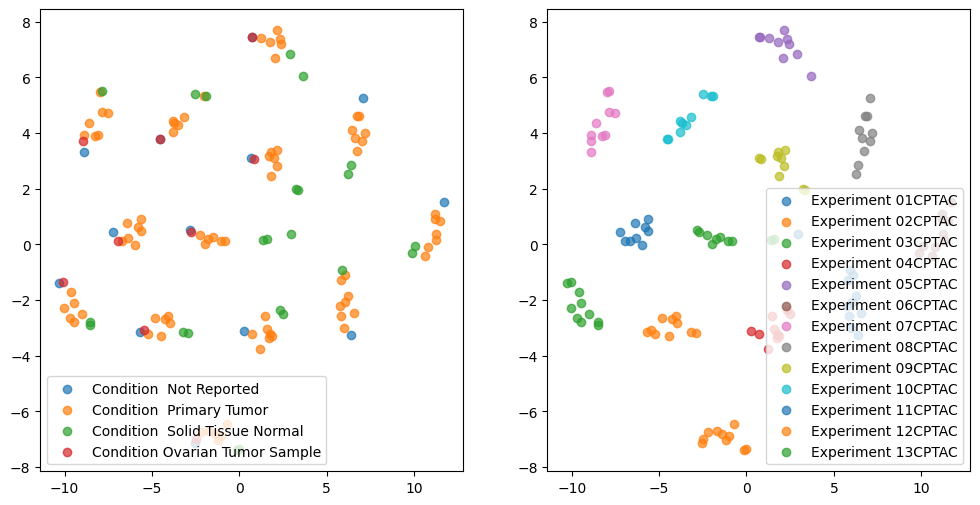

In [13]:
## baseline using TSNE

fig, axes = plt.subplots(1, 2, figsize=(12, 6))




tsne = TSNE(n_components=2, random_state=0)
df_2d = tsne.fit_transform(sample_data_normalized)
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[0].scatter(
        df_2d[indices, 0],
        df_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[0].legend()

unique_experiments = np.unique(experiment_codes)

for experiment in unique_experiments:
    indices = (experiment_codes == experiment)
    axes[1].scatter(
        df_2d[indices, 0],
        df_2d[indices, 1],
        label=f'Experiment {experiment}',
        alpha=0.7
    )
axes[1].legend()



# Direct Autoencoder Clustering

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 2000),
            nn.ReLU(),
            nn.Linear(2000, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 2000),
            nn.ReLU(),
            nn.Linear(2000, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return z, x_reconstructed

class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters, latent_dim):
        super(ClusteringLayer, self).__init__()
        self.cluster_centers = nn.Parameter(torch.randn(n_clusters, latent_dim))

    def forward(self, z):
        # Compute soft assignments (q_ij)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q / torch.sum(q, dim=1, keepdim=True)
        return q

# Step 3: Target Distribution Update
def target_distribution(q):
    weight = q ** 2 / torch.sum(q, dim=0)
    return (weight.t() / torch.sum(weight, dim=1)).t()

In [15]:
def encode_conditions(conditions : list):
    conditions_encoded = list()
    condition_codes = dict()
    next_code = 0
    for condition in conditions:
        if condition not in condition_codes:
            condition_codes[condition] = next_code
            next_code += 1
        conditions_encoded.append(condition_codes[condition])
    return conditions_encoded
encoded_conditions = encode_conditions(conditions)

In [16]:



X_tensor = proteomics_tensor
proteomics_dl = DataLoader(X_tensor, batch_size=64, shuffle=True)
input_dim = proteomics_tensor.shape[1]
latent_dim = 10
pre_training_epochs = 50
train_epochs = 150

y = encoded_conditions
n_clusters = len(np.unique(y))


autoencoder = Autoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)


In [17]:

for epoch in range(pre_training_epochs):  # Pre-train for 50 epochs
    z, X_reconstructed = autoencoder(X_tensor)
    loss = criterion(X_reconstructed, X_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Reconstruction Loss: {loss.item()}")

Epoch 10, Reconstruction Loss: 0.8281627893447876
Epoch 20, Reconstruction Loss: 0.625367283821106
Epoch 30, Reconstruction Loss: 0.44915395975112915
Epoch 40, Reconstruction Loss: 0.28647157549858093
Epoch 50, Reconstruction Loss: 0.1895965039730072


In [18]:
# init the clusterer through kmeans
with torch.no_grad():
    latent_representations = autoencoder.encoder(X_tensor).numpy()
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
kmeans.fit(latent_representations)
initial_cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

clustering_layer = ClusteringLayer(n_clusters, latent_dim)
clustering_layer.cluster_centers.data = initial_cluster_centers

In [19]:
optimizer_dec = torch.optim.Adam(list(autoencoder.parameters()) + list(clustering_layer.parameters()), lr=1e-3)

for epoch in range(train_epochs):  # Train DEC for 50 epochs
    z, X_reconstructed = autoencoder(X_tensor)
    q = clustering_layer(z)
    p = target_distribution(q)
    # KL Divergence Loss
    kl_loss = torch.nn.functional.kl_div(q.log(), p, reduction='batchmean')
    recon_loss = criterion(X_reconstructed, X_tensor)  # Optionally combine with reconstruction loss
    loss = kl_loss + 0.1 * recon_loss
    optimizer_dec.zero_grad()
    loss.backward()
    optimizer_dec.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Total Loss: {loss.item()}, KL Loss: {kl_loss.item()}, Recon Loss: {recon_loss.item()}")


Epoch 10, Total Loss: 0.050204481929540634, KL Loss: 0.0015107473591342568, Recon Loss: 0.48693734407424927
Epoch 20, Total Loss: 0.025651687756180763, KL Loss: 0.0005593785899691284, Recon Loss: 0.2509230971336365
Epoch 30, Total Loss: 0.017761318013072014, KL Loss: 0.00025373720563948154, Recon Loss: 0.17507581412792206
Epoch 40, Total Loss: 0.014907087199389935, KL Loss: 9.867388143902645e-05, Recon Loss: 0.1480841338634491
Epoch 50, Total Loss: 0.012887431308627129, KL Loss: 0.00014366256073117256, Recon Loss: 0.12743768095970154
Epoch 60, Total Loss: 0.011475656181573868, KL Loss: 0.00010116810881299898, Recon Loss: 0.11374488472938538
Epoch 70, Total Loss: 0.010365583933889866, KL Loss: 5.4841315431986004e-05, Recon Loss: 0.10310743004083633
Epoch 80, Total Loss: 0.009505966678261757, KL Loss: 3.540676334523596e-05, Recon Loss: 0.09470559656620026
Epoch 90, Total Loss: 0.008812972344458103, KL Loss: 2.821340058289934e-05, Recon Loss: 0.08784758299589157
Epoch 100, Total Loss: 0.0

In [20]:
with torch.no_grad():
    z, _ = autoencoder(X_tensor)
    q = clustering_layer(z)
    cluster_assignments = torch.argmax(q, dim=1).numpy()
ari = adjusted_rand_score(y, cluster_assignments)
print(f"Adjusted Rand Index (ARI): {ari}")

Adjusted Rand Index (ARI): 0.10227743745686547


In [21]:
def extract_latent_space(model, data_loader):
    model.encoder.eval()
    latent_representations = []
    with torch.no_grad():
        for batch in data_loader:
            ######### NEW ##############
            # x = batch[0]
            # x = x.view(x.size(0), -1)
            ############################
            bach_latent_reepresentation = model.encoder(batch)
           
            latent_representations.append(bach_latent_reepresentation)
    return np.vstack(latent_representations)

# Here fixed model goae -> autoencoder
latent_representations = extract_latent_space(autoencoder, proteomics_tensor)


In [22]:
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

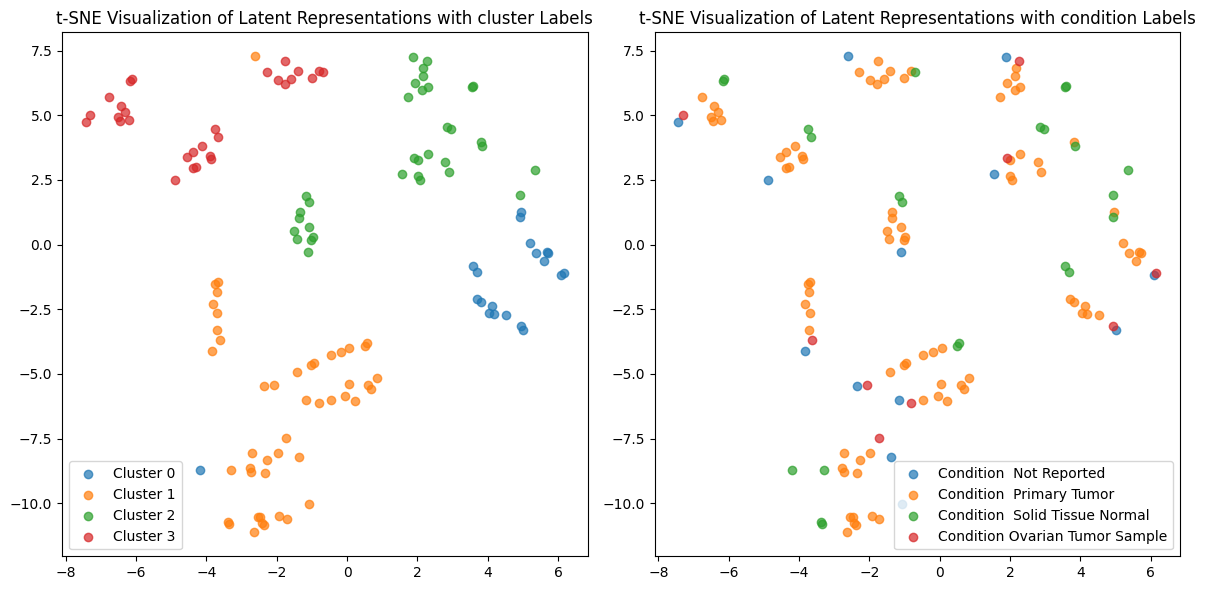

In [23]:

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()


unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

# VAE


In [24]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, latent_dim):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim)
            )
        self.fc_mu = nn.Linear(latent_dim, latent_dim)
        self.fc_var = nn.Linear(latent_dim, latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_var(x)
        return mu, logvar

    def forward(self, x):
        hidden = self.encoder(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_var(hidden)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar


In [25]:
# standard VAE loss
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_divergence

In [26]:
def vae_train(model, optimizer, data_loader, loss_fn, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in data_loader:
            x = batch[0]
            x = x.view(x.size(0), -1)
            optimizer.zero_grad()
            recon_x, mu, logvar = model(x)
            loss = loss_fn(recon_x, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch + 1}, Loss: {total_loss / len(data_loader.dataset)}")
    return model

proteomics_ds = TensorDataset(proteomics_tensor)
proteomics_dl = DataLoader(proteomics_ds, batch_size=64, shuffle=False)
input_dim = proteomics_tensor.shape[1]
hidden_dim_1 = 2000
hidden_dim_2 = 100
latent_dim = 10
epochs = 150

vae_model = VAE(input_dim, hidden_dim_1, hidden_dim_2, latent_dim)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
vae_trained = vae_train(vae_model, optimizer, proteomics_dl, vae_loss, epochs=epochs)


Epoch 1, Loss: 11478.097220552885
Epoch 2, Loss: 11216.481017127404
Epoch 3, Loss: 161421883.20803034
Epoch 4, Loss: 197725465063.45944
Epoch 5, Loss: 11647.850510817309
Epoch 6, Loss: 66339.75907451923
Epoch 7, Loss: 46300.75267427885
Epoch 8, Loss: 10630.226434795673
Epoch 9, Loss: 10200.779942908654
Epoch 10, Loss: 17146.586936598556
Epoch 11, Loss: 16363.76397235577
Epoch 12, Loss: 9426.496529447115
Epoch 13, Loss: 8736.294118088943
Epoch 14, Loss: 8366.788927283655
Epoch 15, Loss: 8175.1502028245195
Epoch 16, Loss: 8096.5908052884615
Epoch 17, Loss: 8103.67255859375
Epoch 18, Loss: 8076.834375
Epoch 19, Loss: 7994.414408052885
Epoch 20, Loss: 7960.101412259615
Epoch 21, Loss: 7879.549286358173
Epoch 22, Loss: 7857.901817908654
Epoch 23, Loss: 7794.141518930289
Epoch 24, Loss: 7752.921499399038
Epoch 25, Loss: 7699.63623046875
Epoch 26, Loss: 7629.792848557692
Epoch 27, Loss: 7565.8120267427885
Epoch 28, Loss: 7508.611410757211
Epoch 29, Loss: 7469.53681640625
Epoch 30, Loss: 7366.

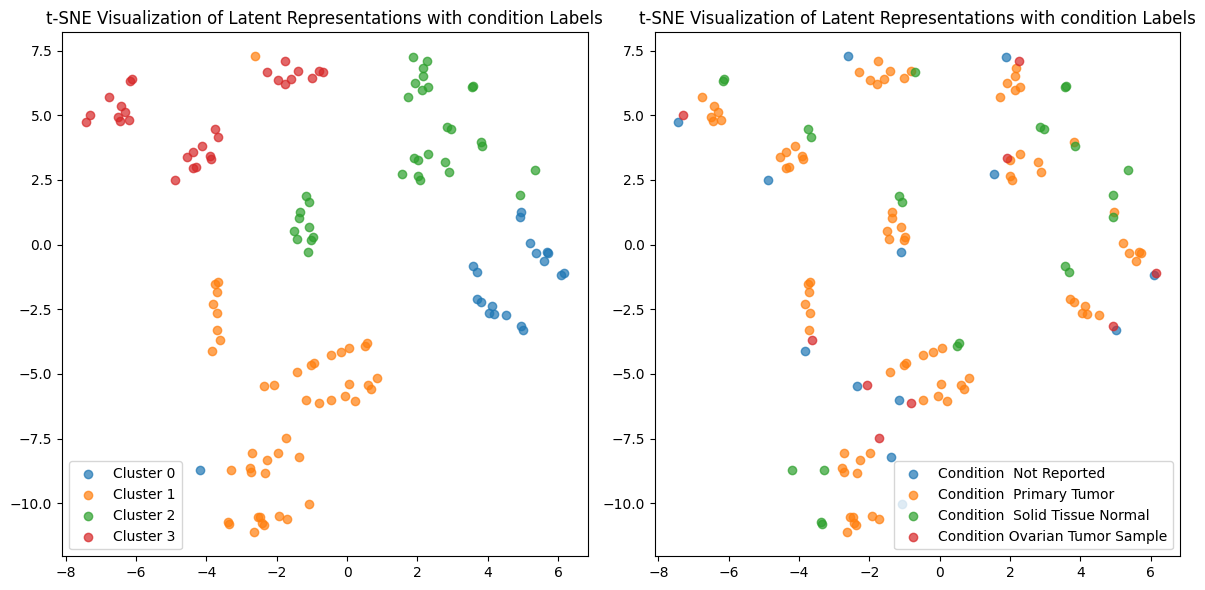

In [27]:
tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[0].legend()

unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()


# Labor normalization

In [28]:
proteomics_tensor_group_normalized = torch.tensor(sample_data_group_normalized, dtype=torch.float32)

In [29]:
norm_proteomics_ds = TensorDataset(proteomics_tensor_group_normalized)
norm_proteomics_dl = DataLoader(proteomics_ds, batch_size=64, shuffle=True)
input_dim = proteomics_tensor_group_normalized.shape[1]
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
latent_dim = 15
epochs = 150

goae_model_norm = GOAE(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
train_goae(goae_model, norm_proteomics_dl, epochs=epochs)

Epoch 1, Loss: 3740.7356952031455
Epoch 2, Loss: 837.704753557841
Epoch 3, Loss: 27.836556037267048
Epoch 4, Loss: 3.391699433326721
Epoch 5, Loss: 1.9288945992787678
Epoch 6, Loss: 2.0176549355189004
Epoch 7, Loss: 1.972846229871114
Epoch 8, Loss: 2.0653186639149985
Epoch 9, Loss: 1.7719490925470989
Epoch 10, Loss: 1.937617580095927
Epoch 11, Loss: 1.7534670035044353
Epoch 12, Loss: 1.7537086804707844
Epoch 13, Loss: 1.7958119710286458
Epoch 14, Loss: 1.8212055365244548
Epoch 15, Loss: 2.0246601899464927
Epoch 16, Loss: 1.8878554900487263
Epoch 17, Loss: 1.7900265057881672
Epoch 18, Loss: 1.8239235877990723
Epoch 19, Loss: 1.7214317719141643
Epoch 20, Loss: 1.8290894428888957
Epoch 21, Loss: 1.608295162518819
Epoch 22, Loss: 1.710796634356181
Epoch 23, Loss: 1.8651944796244304
Epoch 24, Loss: 1.7250733375549316
Epoch 25, Loss: 1.6208747625350952
Epoch 26, Loss: 1.7210652828216553
Epoch 27, Loss: 1.7754959265391033
Epoch 28, Loss: 1.7876773277918498
Epoch 29, Loss: 2.1063011089960733
E

In [30]:
latent_representations = extract_latent_space(goae_model_norm, proteomics_tensor_group_normalized)

In [31]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

In [32]:
latent_representations.shape

(130, 15)

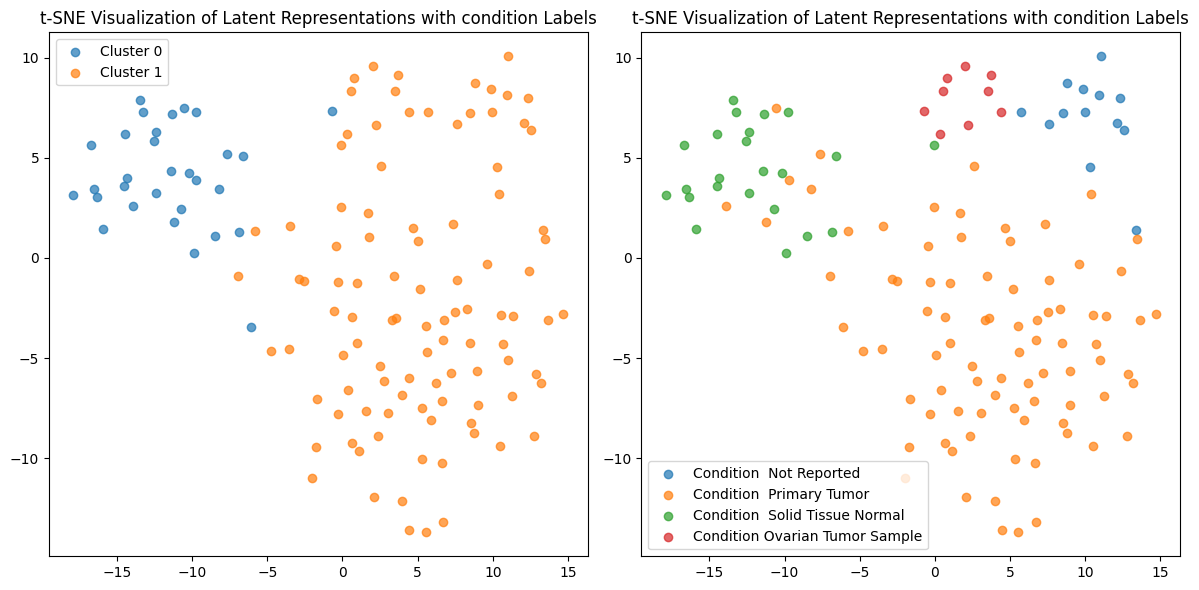

In [33]:
tsne = TSNE(n_components=2, perplexity=15.0)
latent_2d = tsne.fit_transform(latent_representations )

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[0].legend()

unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()


# Ignore correction lables

In [34]:

index = (conditions ==' Primary Tumor') + (conditions == ' Solid Tissue Normal')

filtered_space = latent_representations[index, :]
filtered_conditions = conditions[index]

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
dbscan = DBSCAN(eps=0.06)
optics = OPTICS(min_samples=5, xi=0.085, min_cluster_size=0.05)

dbscan_clustering = dbscan.fit(filtered_space).labels_
optics_clustering = optics.fit(filtered_space).labels_
kmeans_clustering = kmeans.fit(filtered_space).labels_



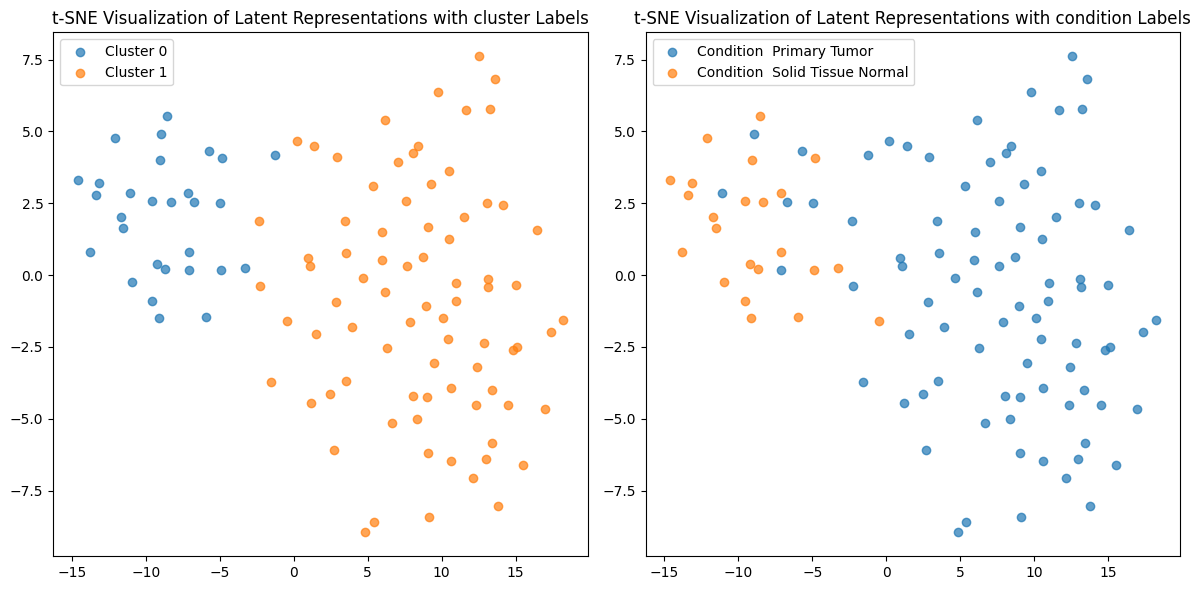

In [37]:
tsne = TSNE(n_components=2, perplexity=15.0)
latent_2d = tsne.fit_transform(filtered_space )

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(kmeans_clustering):
    indices = (kmeans_clustering == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

unique_conditions = np.unique(filtered_conditions)
for condition in unique_conditions:
    indices = (filtered_conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation of Accuracy, Recall, etc 

In [36]:
condition_map = {
    ' Primary Tumor' : 0,
    ' Solid Tissue Normal' : 1
}

encoded_conditions = np.vectorize(condition_map.get)(filtered_conditions)
equality1 = encoded_conditions == kmeans_clustering
equality2 = encoded_conditions != kmeans_clustering
# swich if cluster lables (name of cluster is random)
if np.sum(equality1) < np.sum(equality2):
    encoded_conditions = -1*encoded_conditions + 1


accuracy = accuracy_score(kmeans_clustering, encoded_conditions)
recall = recall_score(kmeans_clustering, encoded_conditions)
f1 = f1_score(kmeans_clustering, encoded_conditions)
precision = precision_score(kmeans_clustering, encoded_conditions)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")

Accuracy: 0.9259259259259259
Recall: 0.9873417721518988
F1 Score: 0.9512195121951219
Precision: 0.9176470588235294
